# PTB-XL — Exploratory Data Analysis
Complete visual exploration of metadata, label distribution, signal quality, and demographic profiles.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import wfdb

import config
import data_load as dl
import data_pipeline as dp

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)
PALETTE = "viridis"
print("Imports OK")


Imports OK


## 1 — Load Data

In [3]:
meta     = dl.load_metadata(config.CFG["data_dir"])
# ✅ FIXED: use dl.load_scp_statements() — filters diagnostic==1 only
scp_diag = dl.load_scp_statements(config.CFG["data_dir"])

Y, mlb, class_names, meta_labeled = dp.build_label_matrix(
    meta, scp_diag, threshold=config.CFG["label_thresh"]
)

print(f"Records: {len(meta_labeled):,}  |  Classes: {class_names}")
display(meta_labeled[["age","sex","diagnostic_superclass","strat_fold"]].head(5))


16:11:05 | INFO     | Loading metadata from D:\DEPI\ECG project\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv...
16:11:06 | INFO     | Dropped 0 duplicate records. 21799 records remain.
16:11:06 | INFO     | Masked ages (300 -> NaN): 293 patients aged >89.
16:11:06 | INFO     | SCP diagnostic codes loaded: 44 codes across 5 superclasses.
16:11:06 | INFO     | Records with >=1 diagnostic label: 21375 (424 dropped).
16:11:06 | INFO     | Label matrix Y shape: (21375, 5) | Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
16:11:06 | INFO     | Class CD    :   4898 (22.9%)
16:11:06 | INFO     | Class HYP   :   2649 (12.4%)
16:11:06 | INFO     | Class MI    :   5469 (25.6%)
16:11:06 | INFO     | Class NORM  :   9514 (44.5%)
16:11:06 | INFO     | Class STTC  :   5108 (23.9%)


Records: 21,375  |  Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


,age,sex,diagnostic_superclass,strat_fold
ecg_id,,,,
1,56.0,1,[NORM],3
2,19.0,0,[NORM],2
3,37.0,1,[NORM],5
4,24.0,0,[NORM],3
5,19.0,1,[NORM],4


## 2 — Class Distribution (Imbalance Check)

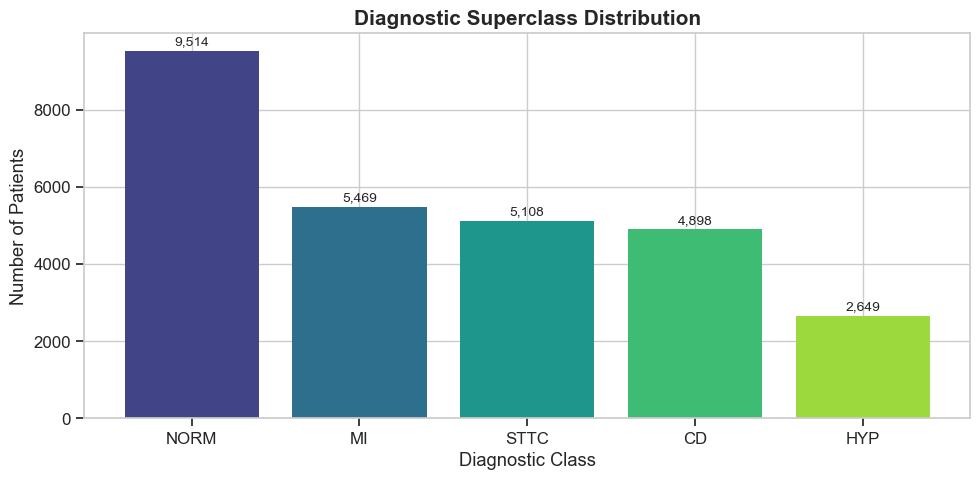

In [4]:
counts    = Y.sum(axis=0)
sort_idx  = np.argsort(counts)[::-1]
srt_counts = counts[sort_idx]
srt_names  = [class_names[i] for i in sort_idx]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(srt_names, srt_counts,
              color=plt.cm.viridis(np.linspace(0.2, 0.85, len(srt_names))))
ax.set_title("Diagnostic Superclass Distribution", fontsize=15, fontweight="bold")
ax.set_ylabel("Number of Patients")
ax.set_xlabel("Diagnostic Class")
for bar, v in zip(bars, srt_counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 80, f"{int(v):,}",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


## 3 — Multi-Label Co-occurrence Heatmap

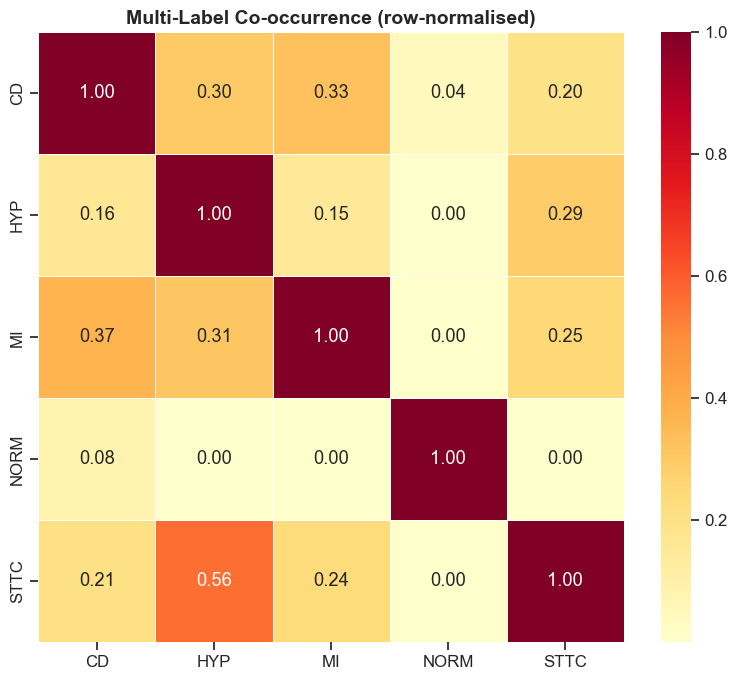

In [5]:
cooc = Y.T @ Y          # shape (n_classes, n_classes)
# Normalize by row so the diagonal is 1.0
cooc_norm = cooc / cooc.diagonal()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cooc_norm, annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names,
            cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Multi-Label Co-occurrence (row-normalised)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 4 — Patient Age Distribution

C:\Users\imana\AppData\Local\Temp\ipykernel_23348\144207704.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(age_per_class, labels=class_names, patch_artist=True,


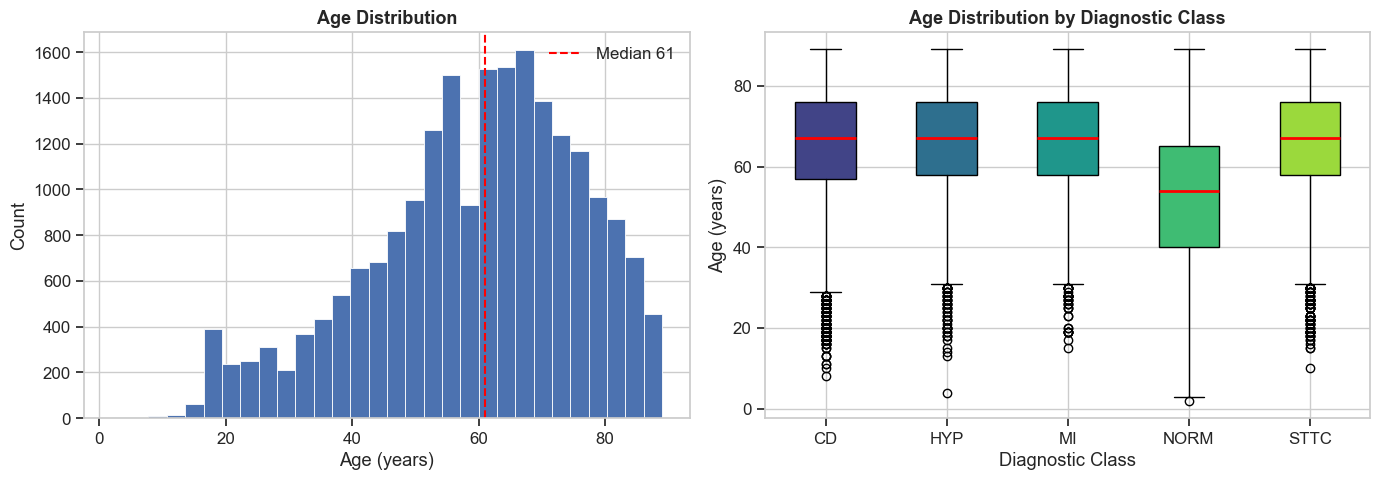

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(meta_labeled["age"].dropna(), bins=30,
             color="#4C72B0", edgecolor="white", linewidth=0.6)
axes[0].set_title("Age Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")
axes[0].axvline(meta_labeled["age"].median(), color="red",
                linestyle="--", label=f"Median {meta_labeled['age'].median():.0f}")
axes[0].legend()

# Box per class
age_per_class = []
for i, cls in enumerate(class_names):
    mask = Y[:, i].astype(bool)
    ages = meta_labeled["age"].values[mask]
    age_per_class.append(ages[~np.isnan(ages)])

bp = axes[1].boxplot(age_per_class, labels=class_names, patch_artist=True,
                     medianprops=dict(color="red", linewidth=2))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(class_names)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_title("Age Distribution by Diagnostic Class", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Age (years)")
axes[1].set_xlabel("Diagnostic Class")

plt.tight_layout()
plt.show()


## 5 — Sex Distribution by Class

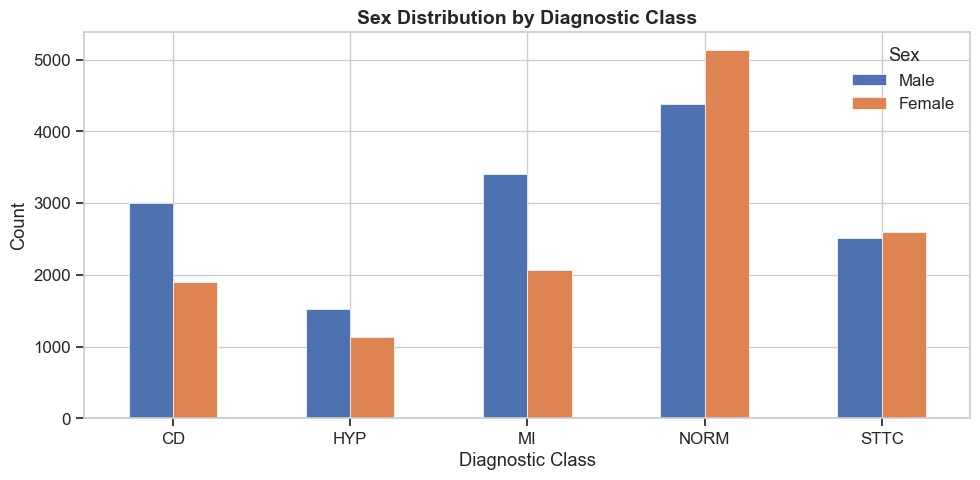

In [7]:
# sex: 0=male, 1=female in PTB-XL
sex_map = {0: "Male", 1: "Female"}
meta_labeled["sex_label"] = meta_labeled["sex"].map(sex_map)

sex_class_counts = []
for i, cls in enumerate(class_names):
    mask = Y[:, i].astype(bool)
    sub  = meta_labeled.iloc[mask]["sex_label"].value_counts()
    sex_class_counts.append({"Class": cls,
                              "Male":   sub.get("Male", 0),
                              "Female": sub.get("Female", 0)})

df_sex = pd.DataFrame(sex_class_counts).set_index("Class")

ax = df_sex.plot(kind="bar", figsize=(10, 5), color=["#4C72B0", "#DD8452"],
                 edgecolor="white", linewidth=0.5)
ax.set_title("Sex Distribution by Diagnostic Class", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("Diagnostic Class")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()


## 6 — Stratified Fold Distribution

16:11:08 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
16:11:08 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


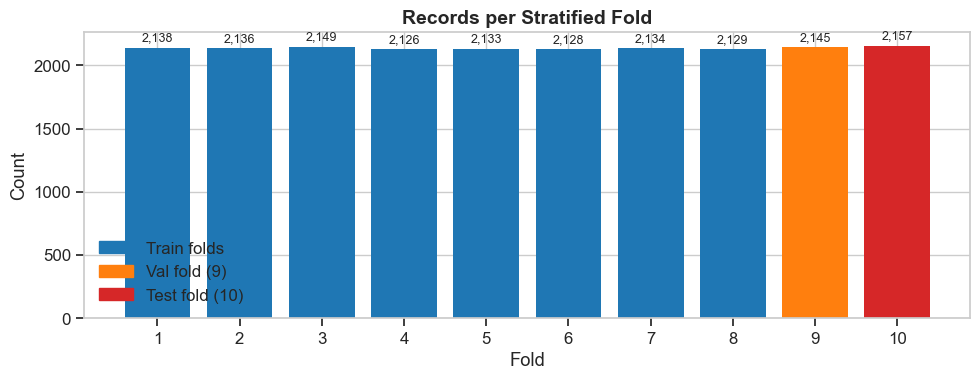

In [8]:
fold_counts = meta_labeled["strat_fold"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(fold_counts.index.astype(str), fold_counts.values,
              color=["#d62728" if f == config.CFG["test_fold"]
                     else "#ff7f0e" if f == config.CFG["val_fold"]
                     else "#1f77b4"
                     for f in fold_counts.index])

legend_patches = [
    mpatches.Patch(color="#1f77b4", label="Train folds"),
    mpatches.Patch(color="#ff7f0e", label=f"Val fold ({config.CFG['val_fold']})"),
    mpatches.Patch(color="#d62728", label=f"Test fold ({config.CFG['test_fold']})"),
]
ax.legend(handles=legend_patches)
ax.set_title("Records per Stratified Fold", fontsize=14, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("Count")
for bar, v in zip(bars, fold_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 30, f"{v:,}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 7 — Full 12-Lead ECG Visualization (raw vs filtered)

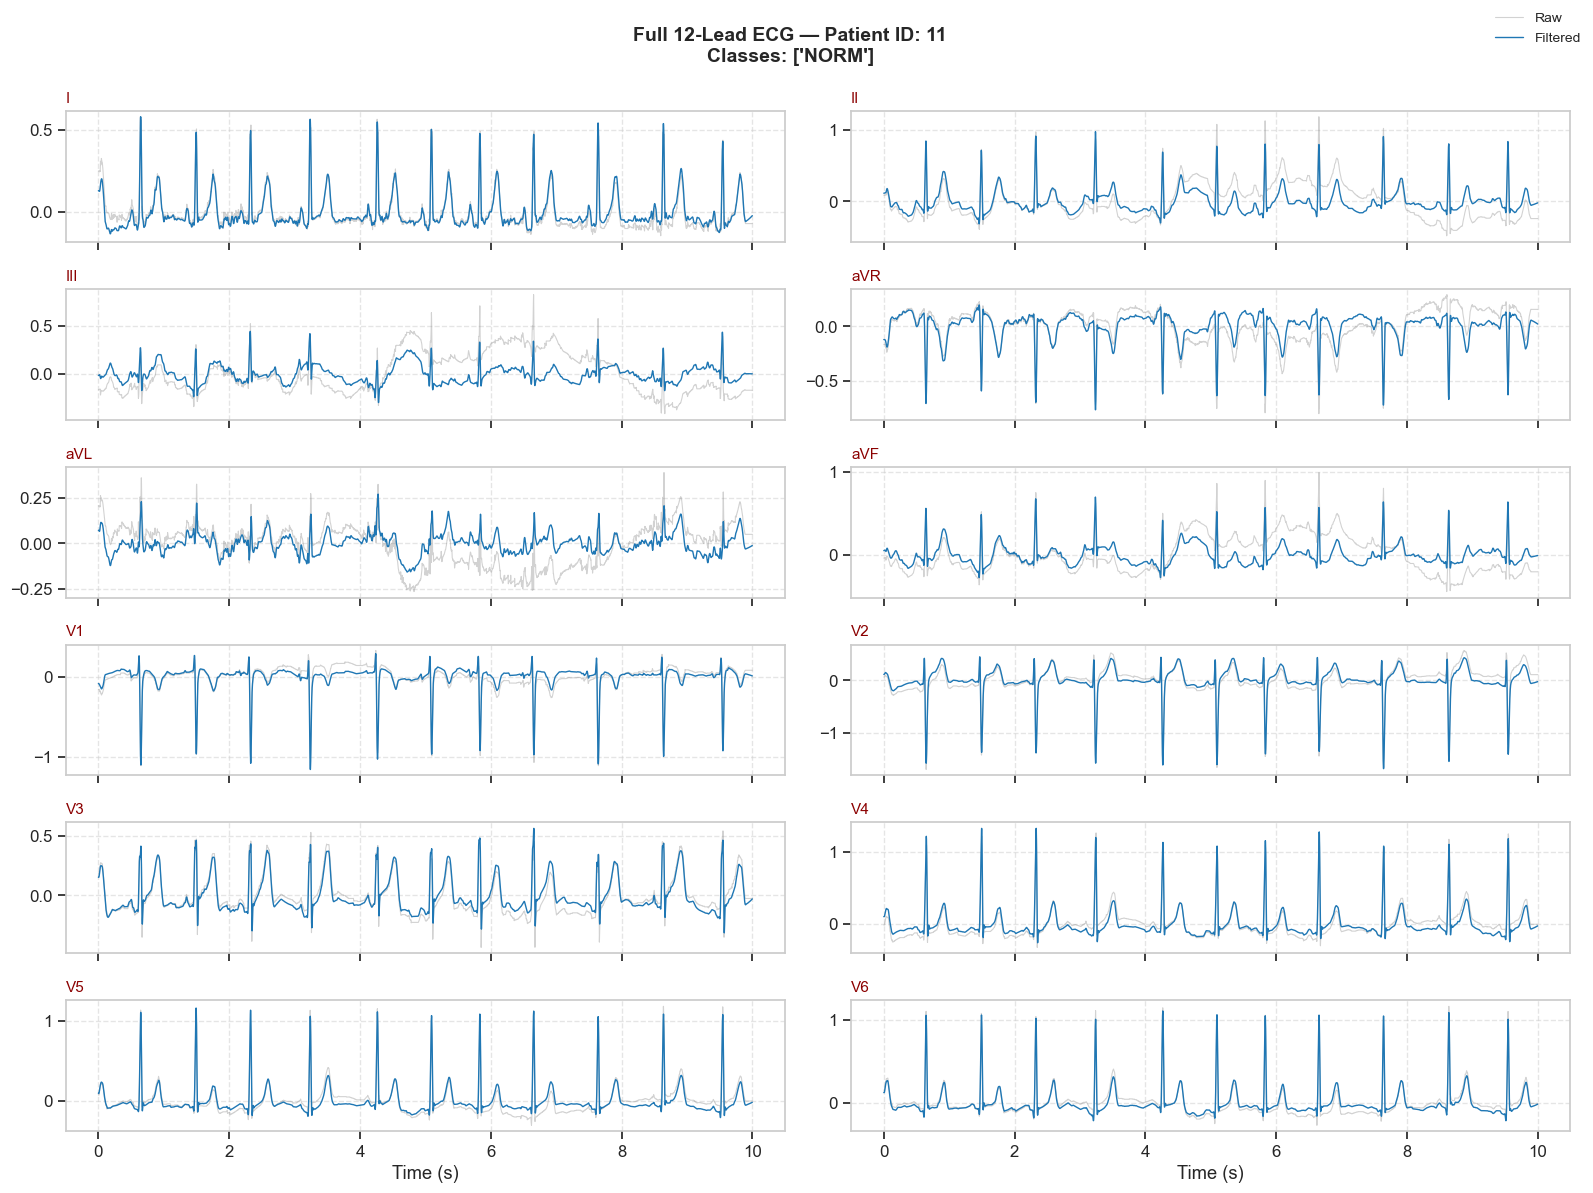

In [9]:
sample_id   = meta_labeled.index[10]
sample_path = os.path.join(config.CFG["data_dir"],
                           meta_labeled.loc[sample_id, "filename_hr"])

sig_raw, _ = wfdb.rdsamp(sample_path)
sig_clean  = dp.clean_single_signal(sig_raw)
sig_filt   = dp.bandpass_filter_single(
    sig_clean, fs=config.CFG["sampling_rate"],
    low=config.CFG["bandpass_low"], high=config.CFG["bandpass_high"],
    order=config.CFG["bandpass_ord"]
)
time_axis = np.arange(sig_filt.shape[0]) / config.CFG["sampling_rate"]

fig, axes = plt.subplots(6, 2, figsize=(16, 12), sharex=True)
fig.suptitle(
    f"Full 12-Lead ECG — Patient ID: {sample_id}\n"
    f"Classes: {meta_labeled.loc[sample_id, 'diagnostic_superclass']}",
    fontsize=14, fontweight="bold"
)
for i, ax in enumerate(axes.flatten()):
    ax.plot(time_axis, sig_raw[:, i],  alpha=0.35, color="gray",  linewidth=0.8, label="Raw")
    ax.plot(time_axis, sig_filt[:, i], color="#1f77b4", linewidth=1,   label="Filtered")
    ax.set_title(config.LEAD_NAMES[i], loc="left", fontsize=11, color="darkred")
    ax.grid(True, linestyle="--", alpha=0.5)
    if i >= 10:
        ax.set_xlabel("Time (s)")
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=10)
plt.tight_layout()
plt.subplots_adjust(top=0.91)
plt.show()


## 8 — Signal Amplitude Statistics per Lead

C:\Users\imana\AppData\Local\Temp\ipykernel_23348\631339290.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=config.LEAD_NAMES, patch_artist=True,


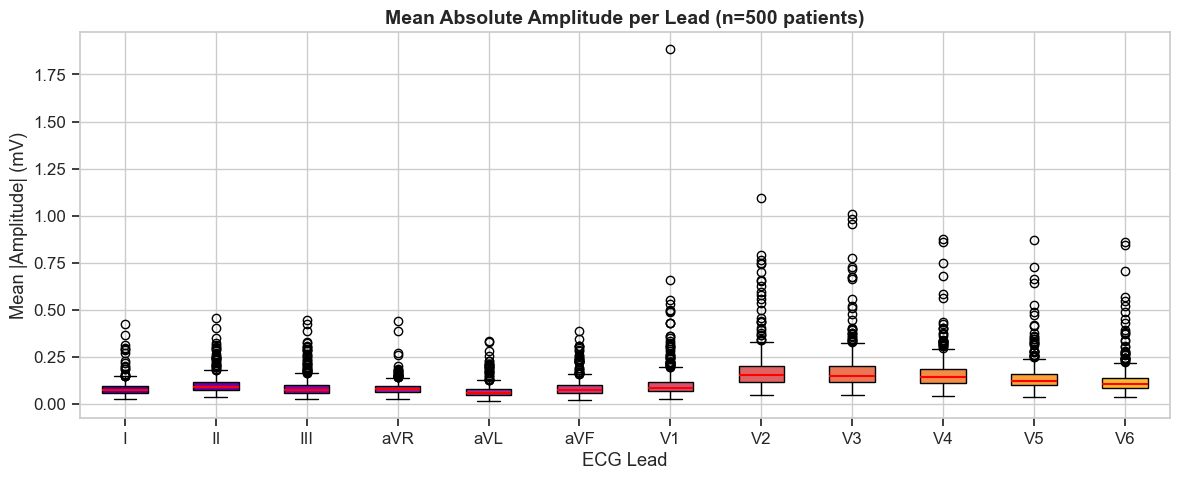

In [10]:
N_SAMPLES = min(500, len(meta_labeled))
lead_stats = {ln: [] for ln in config.LEAD_NAMES}

for idx in range(N_SAMPLES):
    row  = meta_labeled.iloc[idx]
    path = os.path.join(config.CFG["data_dir"], row["filename_hr"])
    try:
        sig, _ = wfdb.rdsamp(path)
        sig    = dp.clean_single_signal(sig)
        if sig is None:
            continue
        for li, ln in enumerate(config.LEAD_NAMES):
            lead_stats[ln].append(np.abs(sig[:, li]).mean())
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(12, 5))
data_for_box = [lead_stats[ln] for ln in config.LEAD_NAMES]
bp = ax.boxplot(data_for_box, labels=config.LEAD_NAMES, patch_artist=True,
                medianprops=dict(color="red", linewidth=1.5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, 12))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title(f"Mean Absolute Amplitude per Lead (n={N_SAMPLES} patients)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Mean |Amplitude| (mV)")
ax.set_xlabel("ECG Lead")
plt.tight_layout()
plt.show()


## 9 — Missing Metadata Summary

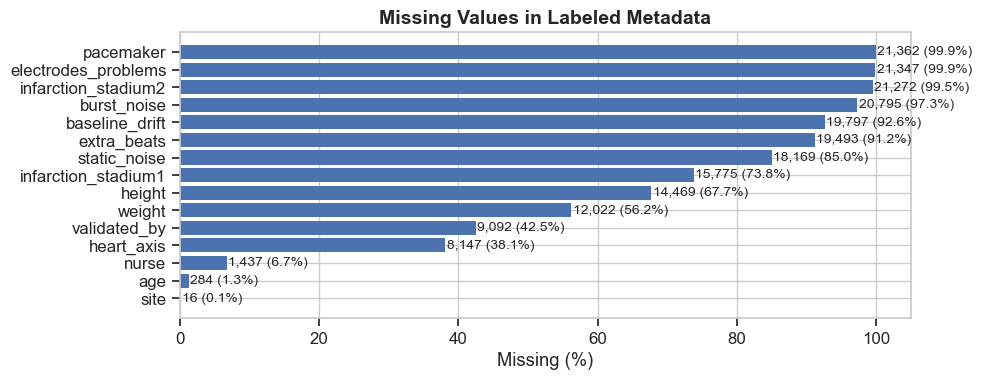

In [11]:
missing = meta_labeled.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No missing values in labeled metadata.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    pct = 100 * missing / len(meta_labeled)
    bars = ax.barh(missing.index[::-1], pct.values[::-1], color="#4C72B0")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values in Labeled Metadata", fontsize=14, fontweight="bold")
    for bar, v, n in zip(bars, pct.values[::-1], missing.values[::-1]):
        ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
                f"{n:,} ({v:.1f}%)", va="center", fontsize=10)
    plt.tight_layout()
    plt.show()


## 10 — Label Count per Patient (Multi-label Profile)

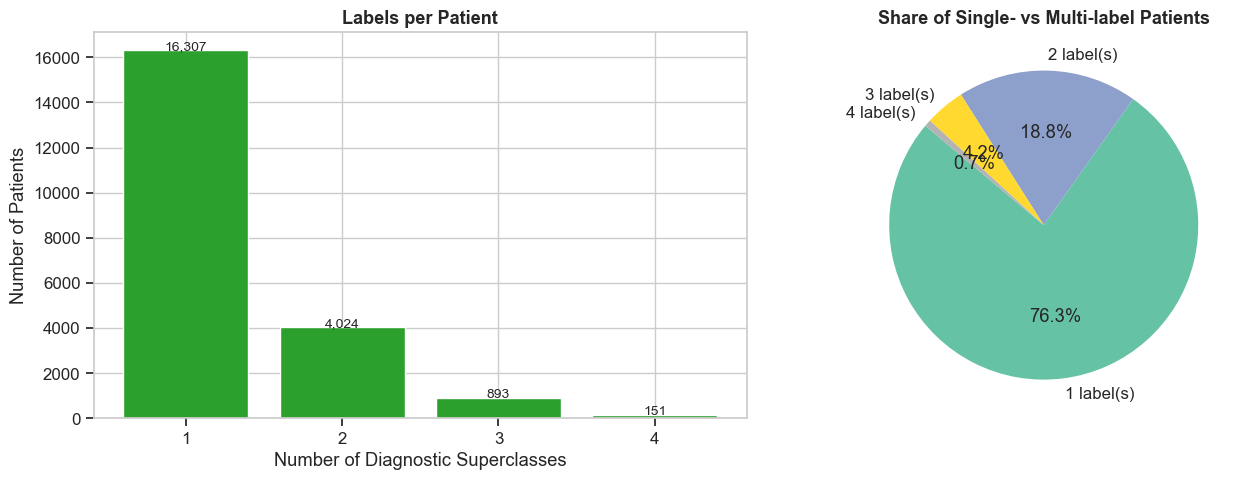

Single-label patients : 16,307
Multi-label  patients : 5,068


In [12]:
label_counts = Y.sum(axis=1)  # how many classes each patient has

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of label count frequency
vals, freq = np.unique(label_counts, return_counts=True)
axes[0].bar(vals.astype(int), freq, color="#2ca02c", edgecolor="white")
axes[0].set_title("Labels per Patient", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Diagnostic Superclasses")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xticks(vals.astype(int))
for v, f in zip(vals, freq):
    axes[0].text(v, f + 30, f"{f:,}", ha="center", fontsize=10)

# Pie chart
axes[1].pie(freq, labels=[f"{int(v)} label(s)" for v in vals],
            autopct="%1.1f%%", startangle=140,
            colors=plt.cm.Set2(np.linspace(0, 1, len(vals))))
axes[1].set_title("Share of Single- vs Multi-label Patients", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Single-label patients : {int(freq[vals==1][0]) if 1 in vals else 0:,}")
print(f"Multi-label  patients : {int(freq[vals > 1].sum()):,}")
